In [107]:
import numpy as np
from numpy.linalg import norm
import math, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import initializers

In [108]:
class PDEenv:
    def __init__(self, boundary):
        self.g = boundary

    def shortestDistance(self, v):
        return min(min(v+1), min(1-v)) ###region (-1, 1)*(-1, 1)*(-1, 1)
    
    def sample_method_inversion_method(self):
        # gen uniform random in range(0, 1)
        u = random.uniform(0, 1)
        v = random.uniform(0, 1)
        # inversion method
        phi = v * 2 * math.pi
        cos_theta = 1 - u
        sin_theta = math.sqrt(1 - cos_theta * cos_theta)
        return np.array([math.cos(phi) * sin_theta, math.sin(phi) * sin_theta, cos_theta])
    
    def ball_Surface_sampling(self):
        uv = np.zeros((2))
        i = norm(uv)**2
        while i > 1 or i == 0:
            uv = (np.random.rand(2) - 0.5)* 2
            i = norm(uv)**2
            
        #print(direction)
        direction = np.zeros((3))
        direction[0] = 2 * uv[0] * math.sqrt(1 - i)
        direction[1] = 2 * uv[1] * math.sqrt(1 - i)
        direction[2] = 1 - 2*i
        return direction
    
    def sampling_rule(self):
        phi = random.uniform(0, 1) * 2 * math.pi
        costheta = random.uniform(-1, 1)
        theta = math.acos(costheta)
        direction = np.zeros((3))
        direction[0] = math.sin(theta) * math.cos(phi)
        direction[1] = math.sin(theta) * math.sin(phi)
        direction[2] = math.cos(theta)
        return direction
    
    def pathGenerator(self, v, eps = 0.01, maxSteps = 80, maxR = 10):
        x0 = v
        path = []
        for step in range(0, maxSteps): 
            path.append(x0)
            r = min([self.shortestDistance(x0), maxR])
            #print(r)
            if r < eps:
                #print(x0)
                #print(self.g(x0))
                return path, self.g(x0)
            
            direction = self.ball_Surface_sampling()
            #print(norm(direction))
            x0 = x0 + r * direction
        return [], 0
    

In [109]:
def boundary(v):
    return v[0] *v[1]* v[2] 

cur_PDE = PDEenv(boundary)
v = np.array([0.5, 0.4, 0.3])
est = 0
for i in range(10000):
    p, e = cur_PDE.pathGenerator(v)
    #print(p)
    est += e
print(est/10000)

0.05675827318347126


In [110]:
boundary(v)

0.06

In [111]:
##### evenly distributed start places
#target = []
#length = range(1, 40)
#width = range(1, 40)
#height = range(1, 40)
#for i in length:
#    for j in width:
#        for k in height:
#            target.append(np.array([i/20 - 1, j/20 - 1, k/20 - 1]))

#print(len(target))

###### pure random start places
target = np.random.rand(60000, 3)
target = 2* target - 1

#####QMC start places
#import scipy.stats as stats
#qmcGenerator = stats.qmc.Sobol(d=2)
#target = qmcGenerator.random(n=40000)
#target = 2* target - 1

In [112]:
paths = []
boundaries = []
maxPath = 0;
for v in target:
    p, b = cur_PDE.pathGenerator(v)
    if len(p) != 0:
        paths.append(p)
        boundaries.append(b)
        if len(p) > maxPath:
            maxPath = len(p)

In [113]:
paths1 = np.zeros((len(paths), maxPath, 3))
for i in range(len(paths)):
    path = paths[i]
    npath = np.array(path)
    if len(path) < maxPath:
        npath = np.concatenate((npath, np.ones((maxPath - len(path), 3)) * np.array(path[len(path) - 1])))

    paths1[i] = npath

print(paths1.shape)

(59995, 79, 3)


In [114]:
paths1 = paths1.reshape(-1, maxPath, 3).astype("float32")
boundary1 = np.array(boundaries).astype("float32")

In [115]:
class NN(keras.Model):
    def __init__(self, units):
        super(NN, self).__init__()
        self.layer1 = keras.layers.Dense(units[0])
        self.layer2 = keras.layers.Dense(units[1])
        self.layer3 = keras.layers.Dense(units[2])
        self.outputs = layers.Dense(4)

    def call(self, input_tensor, training):
        x = self.layer1(input_tensor)
        x = tf.nn.relu(x)
        x = self.layer2(x)
        x = tf.nn.relu(x)
        x = self.layer3(x)
        x = tf.nn.relu(x)
        x = self.outputs(x)
        #print(x.shape)
        return x

In [116]:
class Ysolver(keras.Model):
    # set y as a trainable variable, initialized randomly
    def __init__(self, layer):
        super(Ysolver, self).__init__()
        self.model = NN(layer)

        #self.y = tf.Variable(np.random.uniform(low=-1, high=1, size=[1, 1]),trainable = True, dtype ="float32")

    def call(self, path, training, batch):
        #print(path.shape)
        y_pred = self.model(path[:, 0], training)[:, 0]
        #print(y_pred.shape)
        for i in range(len(path[0]) - 1): ###input path should be (-1, 2) shaped nparray, no len()
            #y = self.Ymodel(path[:, i], training)
            #print(y.shape)
            #z_input = tf.concat([path[:, i],y], 1)
            z = self.model(path[:, i], training)[:, 1:4] #obtain gradients for steps
            diff = path[:, i + 1] - path[:, i]
            #print(diff.shape)
            add = z[:, 0]*diff[:, 0] + z[:, 1]*diff[:, 1] + z[:, 2]*diff[:, 2] #accumulating
            #print(add.shape)
            y_pred += add

        return y_pred

In [117]:
class NNsolver(keras.Model):
    def __init__(self, paths, boundary):
        super(NNsolver, self).__init__()
        self.paths = paths
        self.boundary = np.array(boundary)
        self.model = Ysolver([64, 128, 128])
        self.optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=2e-4 , epsilon=1e-8)

    def loss_fn(self, y_pred, y):
        delta = y_pred - y
        loss = tf.reduce_mean(tf.square(delta))
        return loss

    def train_step(self, cur_path, training, batch_size):           
        return self.model(cur_path, training, batch_size)

    def train(self, batch_size): 
        training_history = []
        for i in range((len(self.paths) - 1)//batch_size + 1):
            batch = batch_size
            if (i + 1) * batch_size > len(paths):
                batch = len(paths) - i * batch_size
            cur_path = self.paths[i*batch_size: i*batch_size + batch]
            cur_bound = self.boundary[i*batch_size: i*batch_size + batch]
                
            with tf.GradientTape() as tape:
                y_pred = self.train_step(cur_path, training = True, batch_size=batch)
                loss = self.loss_fn(y_pred, cur_bound)

            training_vars = self.model.trainable_variables 
            grad = tape.gradient(loss, training_vars)
            #print(grad)
            #print("----------------------------------------------------")
            self.optimizer.apply_gradients(zip(grad, training_vars))
            #print(self.model.Ymodel.trainable_variables)
            training_history.append(loss)

        return training_history

    def train_epoch(self, epoch, batch_size):
        for i in range(epoch):
            cur_history = self.train(batch_size)
            print("epoch: " + str(i) + " loss: "+ str(np.mean(np.array(cur_history))))


In [118]:
training = NNsolver(paths1, boundary1)
training.train_epoch(50, 1024)

epoch: 0 loss: 0.04103632
epoch: 1 loss: 0.01612059
epoch: 2 loss: 0.0090369005
epoch: 3 loss: 0.007592907
epoch: 4 loss: 0.0068599223
epoch: 5 loss: 0.006208332
epoch: 6 loss: 0.0055835578
epoch: 7 loss: 0.00503976
epoch: 8 loss: 0.004590638
epoch: 9 loss: 0.0042401315
epoch: 10 loss: 0.003970984
epoch: 11 loss: 0.0037640529
epoch: 12 loss: 0.0036022416
epoch: 13 loss: 0.0034741072
epoch: 14 loss: 0.0033722492
epoch: 15 loss: 0.0032881561
epoch: 16 loss: 0.0032196157
epoch: 17 loss: 0.0031635694
epoch: 18 loss: 0.0031177865
epoch: 19 loss: 0.0030794234
epoch: 20 loss: 0.0030472835
epoch: 21 loss: 0.0030197508
epoch: 22 loss: 0.002994415
epoch: 23 loss: 0.0029727956
epoch: 24 loss: 0.0029537757
epoch: 25 loss: 0.0029375372
epoch: 26 loss: 0.0029228788
epoch: 27 loss: 0.0029095146
epoch: 28 loss: 0.0028976887
epoch: 29 loss: 0.0028864273
epoch: 30 loss: 0.0028764855
epoch: 31 loss: 0.0028673809
epoch: 32 loss: 0.002859206
epoch: 33 loss: 0.0028518562
epoch: 34 loss: 0.0028446508
epoch: 

In [119]:
v = np.array([0.5, 0.4, 0.3])
training.model.model((v).reshape(1, 3))

<tf.Tensor: shape=(1, 4), dtype=float32, numpy=array([[0.04611967, 0.1466747 , 0.12357566, 0.20277049]], dtype=float32)>

In [148]:
width = range(101)
height = range(101)

X = []
Y = []
Z = []
for i in width:
    for j in height:
        X.append(i/50 - 1)
        Y.append(j/50 - 1)
        Z.append(training.model.model(np.array([i/50-1,j/50-1, 0.8]).reshape([1, 3]).astype("float32")))

X = np.array(X).reshape(101, 101)
Y = np.array(Y).reshape(101, 101)


In [149]:
Z2 = np.array(Z)[:, :, 0].reshape(101, 101)

(101, 101)


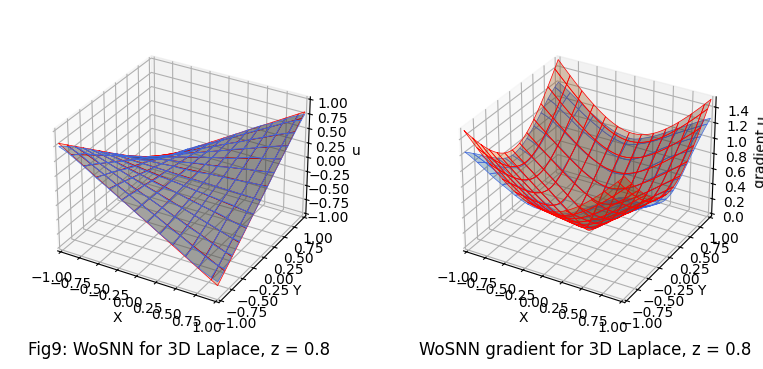

In [150]:
Z1 = X*Y * 0.8
print(Z1.shape)

import matplotlib.pyplot as plt
fig = plt.figure(figsize=plt.figaspect(0.5))
ax = fig.add_subplot(1, 2, 1, projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z2, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='u')

#plt.show()
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Fig9: WoSNN for 3D Laplace, z = 0.8", y = -0.05)

ax = fig.add_subplot(1, 2, 2, projection='3d')
Z3 = np.linalg.norm(np.array(Z)[:, :, 1:4].reshape(-1, 3), axis = 1).reshape(101, 101)
Z1 = np.sqrt(0.64 * X*X + 0.64 * Y*Y + X*X*Y*Y)
# Plot the 3D surface
ax.plot_surface(X, Y, Z3, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(0, 1.5),
       xlabel='X', ylabel='Y', zlabel='gradient u')
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("WoSNN gradient for 3D Laplace, z = 0.8", y = -0.05)
plt.savefig('WoSNNMC3Dlaplace08.png', bbox_inches='tight')

(101, 101)


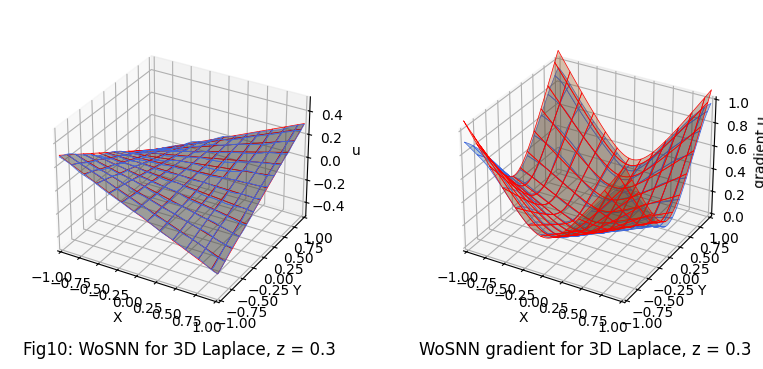

In [151]:
Z = []
for i in width:
    for j in height:
        Z.append(training.model.model(np.array([i/50-1,j/50-1, 0.3]).reshape([1, 3]).astype("float32")))
Z2 = np.array(Z)[:, :, 0].reshape(101, 101)
Z1 = X*Y * 0.3
print(Z1.shape)

import matplotlib.pyplot as plt
fig = plt.figure(figsize=plt.figaspect(0.5))
ax = fig.add_subplot(1, 2, 1, projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z2, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-0.5, 0.5),
       xlabel='X', ylabel='Y', zlabel='u')

#plt.show()
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Fig10: WoSNN for 3D Laplace, z = 0.3", y = -0.05)

ax = fig.add_subplot(1, 2, 2, projection='3d')
Z3 = np.linalg.norm(np.array(Z)[:, :, 1:4].reshape(-1, 3), axis = 1).reshape(101, 101)
Z1 = np.sqrt(0.09 * X*X + 0.09 * Y*Y + X*X*Y*Y)
# Plot the 3D surface
ax.plot_surface(X, Y, Z3, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(0, 1),
       xlabel='X', ylabel='Y', zlabel='gradient u')
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("WoSNN gradient for 3D Laplace, z = 0.3", y = -0.05)
plt.savefig('WoSNNMC3Dlaplace03.png', bbox_inches='tight')